# Day 2 · 06 — Image segmentation: a label for every pixel

| Task | Question | Output |
|---|---|---|
| classification (Notebook 01) | *what* is in the picture? | 1 label: "person" |
| detection (Live demo) | *where* roughly? | boxes around each person |
| **segmentation (this notebook)** | **exactly which pixels?** | **a second picture, the *mask*: every pixel gets a class** |

Segmentation is used for self-driving cars (road / car / person), medical scans (tumour / healthy), photo apps (background removal)
and satellite maps (buildings / fields / water).

**Case study:** 🚶 find the **people** in street photos, pixel by pixel. Open-source dataset **Penn-Fudan** (170 photos, University of Pennsylvania).

| Step | What we do |
|---|---|
| 1 | look at photos and masks |
| 2 | learn how to score a mask (**IoU**) and why pixel accuracy lies |
| 3 | 🎁 an **open-source pretrained** model (torchvision LR-ASPP), used as it is |
| 4 | 🏗️ **our own U-Net**, trained from zero on 120 photos |
| 5 | 🎯 **fine-tune** the pretrained model on our photos |
| 6 | compare all three |

⏱️ Runs in about 10–15 minutes on a CPU (most of it is Step 4). Downloads 54 MB of photos + 13 MB of pretrained weights.
Interactive version: `Training_Visualized/14_image_segmentation.html`.

## Step 0 — Setup

Download Penn-Fudan (once), load all 170 photos and masks, and make them all **224 × 224**.

* Photos are resized smoothly (bilinear). **Masks must be resized with `nearest`**: a pixel is either person (1) or background (0), never 0.37.
* In the dataset each person has their own number (1, 2, 3…). We only want "person or not", so every number > 0 becomes 1.

In [1]:
import io, time, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision.models.segmentation import lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights

torch.manual_seed(0)
torch.set_num_threads(max(1, torch.get_num_threads()))
DATA_DIR = Path("..") / "data"
ROOT = DATA_DIR / "PennFudanPed"
SIZE = 224
MEAN, STD = torch.tensor([0.485, 0.456, 0.406])[:, None, None], torch.tensor([0.229, 0.224, 0.225])[:, None, None]

if not (ROOT / "PNGImages").exists():
    for url in ["https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip",
                "https://web.archive.org/web/2023id_/https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"]:
        try:
            with urllib.request.urlopen(url, timeout=120) as r:
                zipfile.ZipFile(io.BytesIO(r.read())).extractall(DATA_DIR)
            break
        except Exception as e:
            print("download failed, trying the next mirror:", e)

photos, masks = [], []
for img_path in sorted((ROOT / "PNGImages").glob("*.png")):
    img = Image.open(img_path).convert("RGB").resize((SIZE, SIZE), Image.BILINEAR)
    mask = Image.open(ROOT / "PedMasks" / f"{img_path.stem}_mask.png").resize((SIZE, SIZE), Image.NEAREST)
    photos.append(torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255)      # (3, 224, 224) in 0..1
    masks.append(torch.from_numpy((np.array(mask) > 0).astype(np.int64)))                # (224, 224) of 0 / 1
photos, masks = torch.stack(photos), torch.stack(masks)

perm = torch.randperm(len(photos), generator=torch.Generator().manual_seed(42))
train_idx, test_idx = perm[:120], perm[120:]                  # 120 to learn from, 50 to test on
print("photos:", tuple(photos.shape), "| masks:", tuple(masks.shape), "| train", len(train_idx), "/ test", len(test_idx))

photos: (170, 3, 224, 224) | masks: (170, 224, 224) | train 120 / test 50


## Step 1 — Look at the data

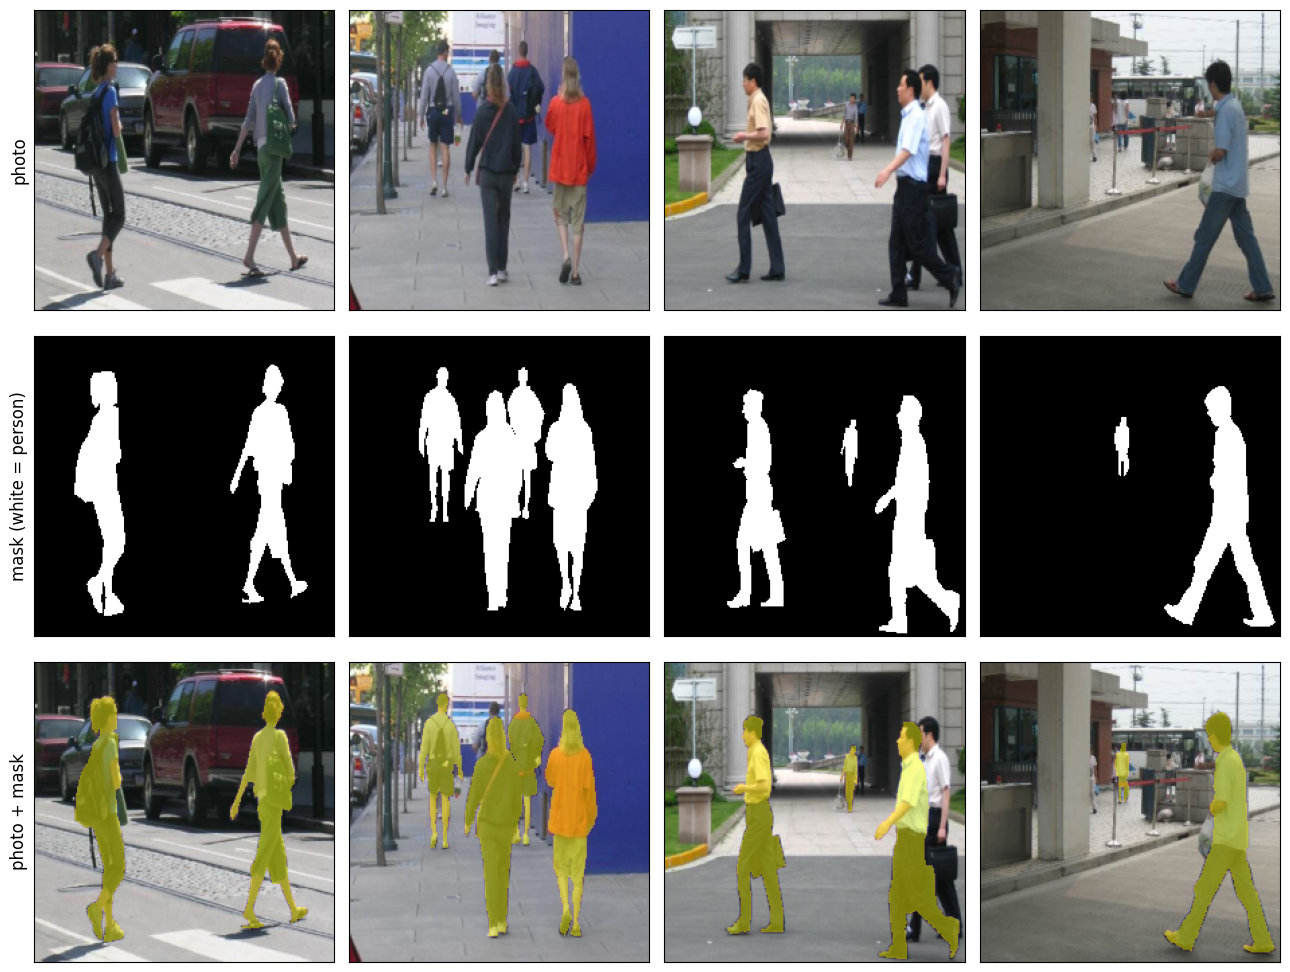

pixels that are 'person' in the test photos: 16.7 %


In [2]:
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for col, i in enumerate(train_idx[:4].tolist()):
    axes[0, col].imshow(photos[i].permute(1, 2, 0))
    axes[1, col].imshow(masks[i], cmap="gray")
    axes[2, col].imshow(photos[i].permute(1, 2, 0)); axes[2, col].imshow(masks[i], cmap="spring", alpha=0.45 * masks[i].float())
for row, title in enumerate(["photo", "mask (white = person)", "photo + mask"]):
    axes[row, 0].set_ylabel(title, fontsize=12)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

person_share = masks[test_idx].float().mean().item()
print(f"pixels that are 'person' in the test photos: {100 * person_share:.1f} %")

👀 **What to notice:** the mask is just **another picture**, the same size as the photo, with one number per pixel.
Training a segmentation model = teaching it to **draw this mask** by itself.

## Step 2 — How good is a mask? IoU, not pixel accuracy

Look at the last line above: most pixels are **background**. A lazy model that answers "background" for every pixel is right
for most pixels, and finds **no person at all**. So we use **IoU** (Intersection over Union):

```
          pixels that are person in BOTH (predicted AND true)
IoU  =   ─────────────────────────────────────────────────────      0 = no overlap … 1 = perfect
          pixels that are person in EITHER (predicted OR true)
```

Rough guide for people: IoU **> 0.5** okay, **> 0.7** good, **> 0.85** excellent.

In [3]:
def scores(pred, true):
    """pred, true: tensors of 0/1 with the same shape (all test photos together)."""
    inter = ((pred == 1) & (true == 1)).sum().item()
    union = ((pred == 1) | (true == 1)).sum().item()
    return {"IoU": round(inter / max(union, 1), 3),
            "pixel_accuracy_%": round(100 * (pred == true).float().mean().item(), 1)}

results = {}
results["😴 always 'background'"] = scores(torch.zeros_like(masks[test_idx]), masks[test_idx])
results

{"😴 always 'background'": {'IoU': 0.0, 'pixel_accuracy_%': 83.3}}

👀 A high pixel accuracy with **IoU = 0**. Never judge a segmentation model by pixel accuracy alone.

## Step 3 — 🎁 An open-source pretrained model, as it is

**LR-ASPP MobileNetV3** from torchvision is a small segmentation model (3 million numbers) that was trained by others on
the big COCO dataset with 21 classes. One of them is **"person"** (class 15). We don't train anything: download and use.

How it works inside (the same idea as every segmentation model):

```
photo ──► ENCODER (MobileNetV3, like Notebook 01) ──► small map of features ──► DECODER / head ──► 21 scores per pixel
224×224    shrinks the picture, learns WHAT is there     (28×28 … 14×14)          grows it back      ──► pick the best
                                                                                   to 224×224          class per pixel = mask
```

In [4]:
def normalise(x):
    return (x - MEAN) / STD

@torch.inference_mode()
def predict(model, idx, person_class=1, batch=10):
    """Mask (0/1) for the photos in idx. person_class = which output channel means 'person'."""
    model.eval()
    out = []
    for s in range(0, len(idx), batch):
        logits = model(normalise(photos[idx[s:s + batch]]))
        logits = logits["out"] if isinstance(logits, dict) else logits       # torchvision models return a dict
        out.append((logits.argmax(1) == person_class).long())
    return torch.cat(out)

pretrained = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.DEFAULT)
classes = LRASPP_MobileNet_V3_Large_Weights.DEFAULT.meta["categories"]
print("pretrained classes:", classes)
print(f"size: {sum(p.numel() for p in pretrained.parameters()):,} numbers")

start = time.perf_counter()
pred_pretrained = predict(pretrained, test_idx, person_class=classes.index("person"))
print(f"⏱️ {1000 * (time.perf_counter() - start) / len(test_idx):.0f} ms per photo")
results["🎁 pretrained, as it is"] = scores(pred_pretrained, masks[test_idx])
results["🎁 pretrained, as it is"]

pretrained classes: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
size: 3,221,538 numbers


⏱️ 42 ms per photo


{'IoU': 0.656, 'pixel_accuracy_%': 92.5}

👀 **What to notice**

* **IoU ≈ 0.66 with zero training.** The model has never seen these photos, but it already finds people, because "person" was one of its 21 classes. This is the power of open-source pretrained models.
* It is not perfect, for two reasons you will see in the pictures of Step 6:
  * its masks are **smooth blobs** that spill over the edges. LR-ASPP decides at 1/8 of the picture size and then just stretches the answer up;
  * it also finds people that Penn-Fudan's masks **don't mark** (small people far away, half-hidden people). For our scoring these count as mistakes. **Your labels define what "right" means.**

## Step 4 — 🏗️ Our own model: a small U-Net, from zero

The **U-Net** (2015, made for medical images) is the classic segmentation network. It looks like a **U**:

```
 224 ──conv──► 224 ─────────────── skip ───────────────► 224 ──conv──► 2 scores per pixel
               │ pool                                   ▲ up
               112 ──conv──► 112 ────── skip ──────► 112 ─┘
                             │ pool                  ▲ up
                             56 ──conv──► 56 ─skip─► 56
                                          │ pool     ▲ up
                                          28 ─conv─► 28      ← the bottom: small but knows WHAT is there
     ENCODER (going down: WHAT)                 DECODER (going up: WHERE)
```

* Going **down**, the picture gets smaller and the network understands *what* is there, but loses *where* exactly.
* Going **up**, it grows the picture back.
* The **skip connections** copy the sharp details from the way down to the way up, so the edges of the mask are sharp.

We train it on only **120 photos**, with the augmentation from Notebook 05. Important: **flip the photo AND its mask together**,
otherwise the mask no longer fits the person.

In [5]:
def conv_block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                         nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU())

class SmallUNet(nn.Module):
    def __init__(self, c=(16, 32, 64, 128), classes=2):
        super().__init__()
        self.down = nn.ModuleList([conv_block(3, c[0]), conv_block(c[0], c[1]), conv_block(c[1], c[2])])
        self.bottom = conv_block(c[2], c[3])
        self.up = nn.ModuleList([nn.ConvTranspose2d(c[3], c[2], 2, stride=2), nn.ConvTranspose2d(c[2], c[1], 2, stride=2),
                                 nn.ConvTranspose2d(c[1], c[0], 2, stride=2)])
        self.after = nn.ModuleList([conv_block(2 * c[2], c[2]), conv_block(2 * c[1], c[1]), conv_block(2 * c[0], c[0])])
        self.head = nn.Conv2d(c[0], classes, 1)                   # 1×1 conv: 2 scores for every pixel

    def forward(self, x):
        skips = []
        for block in self.down:                                   # encoder: 224 → 112 → 56 → 28
            x = block(x); skips.append(x); x = F.max_pool2d(x, 2)
        x = self.bottom(x)
        for up, after, skip in zip(self.up, self.after, reversed(skips)):   # decoder: 28 → 56 → 112 → 224
            x = after(torch.cat([up(x), skip], dim=1))            # ← the skip connection
        return self.head(x)

def augment(x, y):
    """The SAME random flip for the photo and its mask, plus a little brightness change for the photo only."""
    flip = torch.rand(len(x)) < 0.5
    x, y = x.clone(), y.clone()
    x[flip], y[flip] = x[flip].flip(-1), y[flip].flip(-1)
    x = (x * (0.8 + 0.4 * torch.rand(len(x), 1, 1, 1))).clamp(0, 1)
    return x, y

def train(model, epochs, lr, batch=8, head=lambda out: out):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()                               # the classification loss, for every pixel, averaged
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train(); total = 0
        order = train_idx[torch.randperm(len(train_idx))]
        for s in range(0, len(order), batch):
            x, y = augment(photos[order[s:s + batch]], masks[order[s:s + batch]])
            loss = loss_fn(head(model(normalise(x))), y)
            opt.zero_grad(); loss.backward(); opt.step(); total += loss.item()
        if epoch % max(1, epochs // 5) == 0 or epoch == epochs:
            iou = scores(predict(model, test_idx), masks[test_idx])["IoU"]
            print(f"epoch {epoch:2d}: loss {total / (len(order) / batch):.3f} | test IoU {iou:.3f} | ⏱️ {time.perf_counter() - start:.0f} s")
    return time.perf_counter() - start

torch.manual_seed(0)
unet = SmallUNet()
print(f"U-Net size: {sum(p.numel() for p in unet.parameters()):,} numbers\n")
unet_time = train(unet, epochs=25, lr=2e-3)
results["🏗️ our U-Net, from zero"] = scores(predict(unet, test_idx), masks[test_idx])
results["🏗️ our U-Net, from zero"]

U-Net size: 483,458 numbers



epoch  5: loss 0.290 | test IoU 0.476 | ⏱️ 103 s


epoch 10: loss 0.223 | test IoU 0.497 | ⏱️ 220 s


epoch 15: loss 0.187 | test IoU 0.639 | ⏱️ 332 s


epoch 20: loss 0.166 | test IoU 0.596 | ⏱️ 446 s


epoch 25: loss 0.147 | test IoU 0.682 | ⏱️ 569 s


{'IoU': 0.682, 'pixel_accuracy_%': 93.8}

👀 **What to notice**

* From zero, with only **120 photos**, the U-Net reaches an IoU of about **0.68**. It even beats the pretrained model used as it is, because it learned exactly **our** masks (which people count, where the edge is).
* But it is **slow** (the longest step of this notebook) and **bumpy**: IoU goes up and down between checks. With so few photos, every epoch changes the model a lot.
* It is small: about 0.5 million numbers, 6× fewer than LR-ASPP.

## Step 5 — 🎯 Fine-tune the pretrained model on our photos

Best of both worlds (transfer learning, like Notebook 01):

1. keep the pretrained **encoder**: it already knows edges, shapes, and what people look like;
2. replace the last layers (21 classes) with new ones for our **2 classes**: background, person;
3. train everything for a few epochs with a **small learning rate**, so we adjust the knowledge instead of destroying it.

In [6]:
torch.manual_seed(0)
finetuned = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.DEFAULT)
finetuned.classifier.low_classifier = nn.Conv2d(finetuned.classifier.low_classifier.in_channels, 2, 1)    # new: 2 classes
finetuned.classifier.high_classifier = nn.Conv2d(finetuned.classifier.high_classifier.in_channels, 2, 1)

finetune_time = train(finetuned, epochs=8, lr=3e-4, head=lambda out: out["out"])
results["🎯 pretrained + fine-tuned"] = scores(predict(finetuned, test_idx), masks[test_idx])
results["🎯 pretrained + fine-tuned"]

epoch  1: loss 0.411 | test IoU 0.616 | ⏱️ 25 s


epoch  2: loss 0.220 | test IoU 0.629 | ⏱️ 46 s


epoch  3: loss 0.180 | test IoU 0.630 | ⏱️ 67 s


epoch  4: loss 0.163 | test IoU 0.644 | ⏱️ 90 s


epoch  5: loss 0.151 | test IoU 0.681 | ⏱️ 109 s


epoch  6: loss 0.142 | test IoU 0.689 | ⏱️ 129 s


epoch  7: loss 0.135 | test IoU 0.701 | ⏱️ 152 s


epoch  8: loss 0.129 | test IoU 0.707 | ⏱️ 173 s


{'IoU': 0.707, 'pixel_accuracy_%': 93.9}

## Step 6 — Compare all three

,IoU,pixel_accuracy_%,training_time
😴 always 'background',0.000,83.3,—
"🎁 pretrained, as it is",0.656,92.5,0 s (trained by others)
"🏗️ our U-Net, from zero",0.682,93.8,569 s
🎯 pretrained + fine-tuned,0.707,93.9,173 s


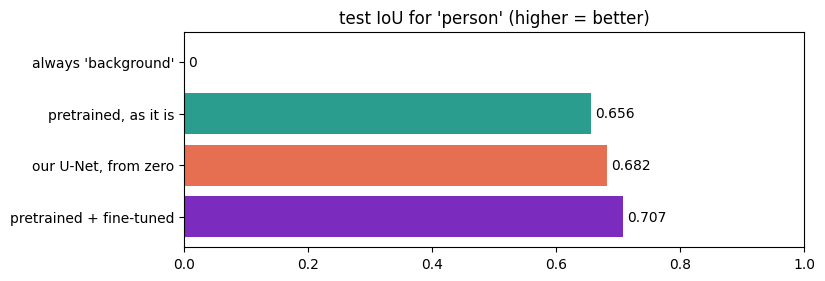

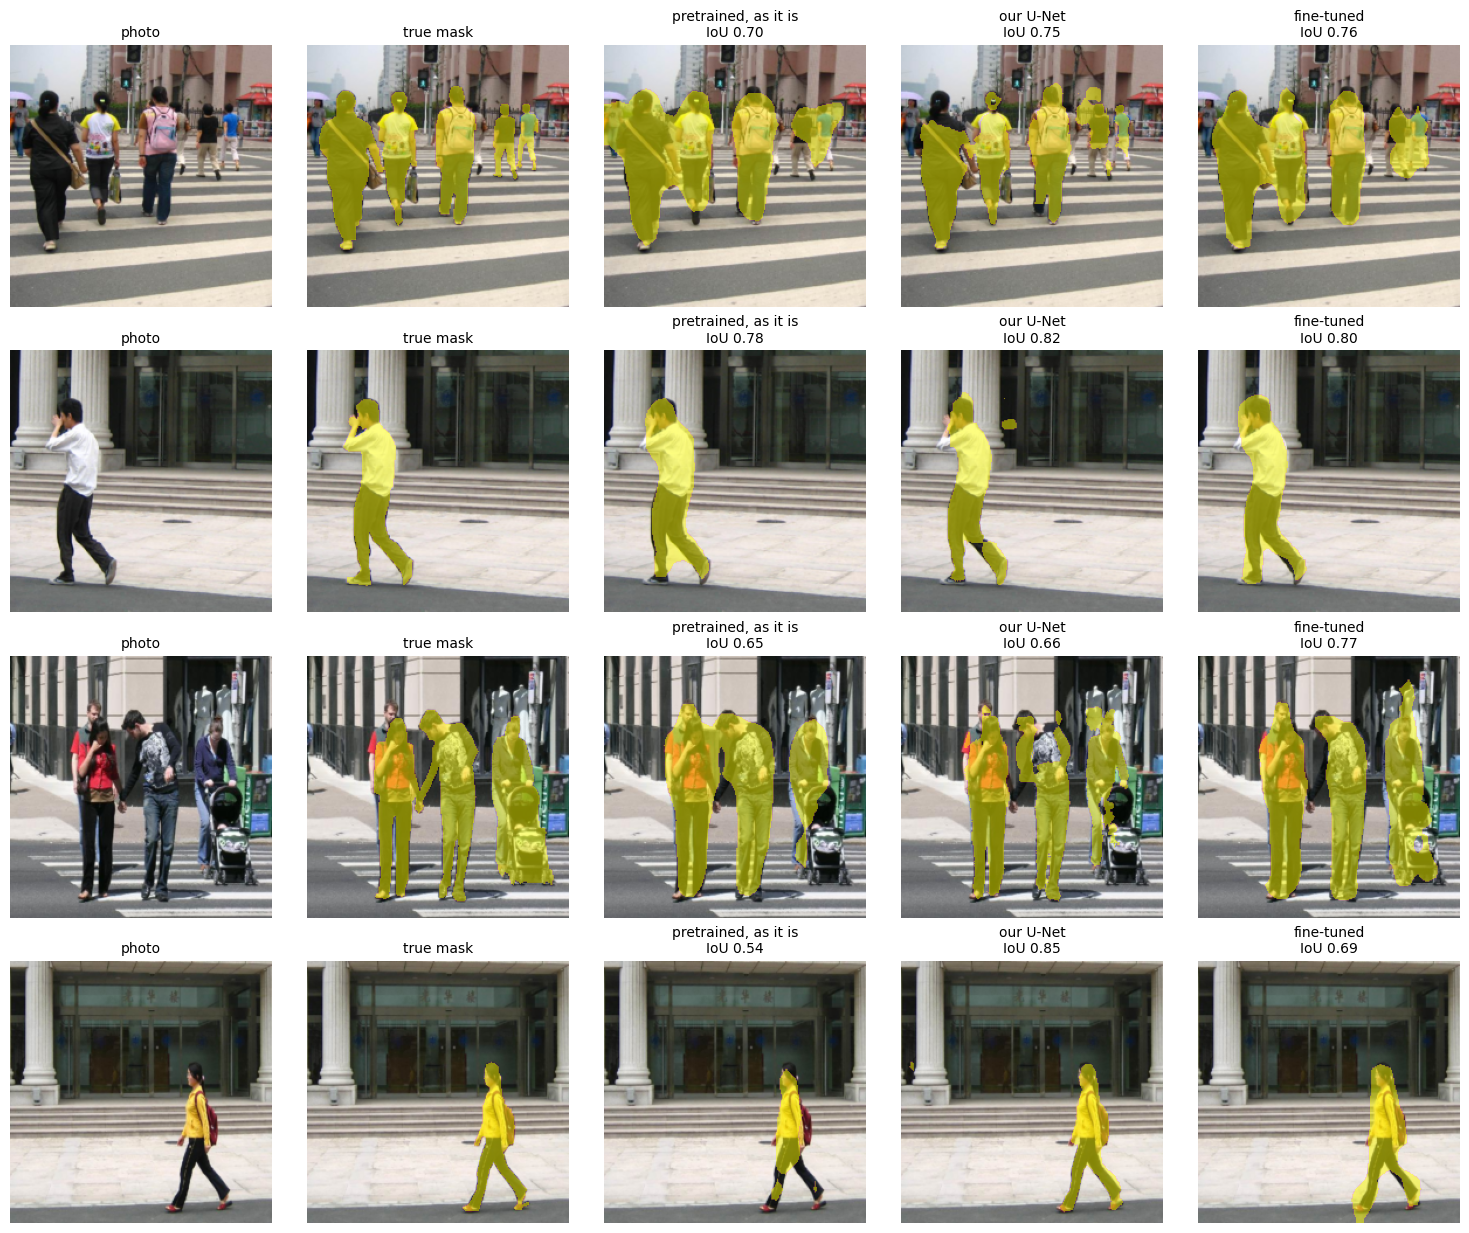

In [7]:
table = pd.DataFrame(results).T
table["training_time"] = ["—", "0 s (trained by others)", f"{unet_time:.0f} s", f"{finetune_time:.0f} s"]
display(table)

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh([n.split(" ", 1)[1] for n in table.index], table["IoU"], color=["#888", "#2a9d8f", "#e76f51", "#7b2cbf"])
ax.bar_label(bars, padding=3); ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_title("test IoU for 'person' (higher = better)")
plt.show()

pred_unet, pred_ft = predict(unet, test_idx), predict(finetuned, test_idx)
show = [0, 7, 19, 33]
fig, axes = plt.subplots(len(show), 5, figsize=(15, 3.1 * len(show)))
for row, k in enumerate(show):
    i = test_idx[k]
    for col, (m, title) in enumerate([(None, "photo"), (masks[i], "true mask"), (pred_pretrained[k], "pretrained, as it is"),
                                      (pred_unet[k], "our U-Net"), (pred_ft[k], "fine-tuned")]):
        ax = axes[row, col]; ax.imshow(photos[i].permute(1, 2, 0))
        if m is not None:
            ax.imshow(m, cmap="spring", alpha=0.5 * m.float())
            if col > 1:
                title += f"\nIoU {scores(m, masks[i])['IoU']:.2f}"
        ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

👀 **What to notice**

* **Fine-tuning wins**, and it trains in about a quarter of the U-Net's time: it starts from knowledge and only has to learn our idea of "person".
* Look at the **edges**. The U-Net's masks are **sharp** (skip connections!) but have **holes and stray blobs**: it misses dark clothes and sometimes marks a patch of the background, because 120 photos are not enough to learn well **what** a person is. The pretrained and fine-tuned masks are the opposite: they **know** what a person is, but draw **softer, blobby** edges.
* **Pixel accuracy** is above 90 % for all three models, and even 83 % for "all background". It hides the real differences. IoU shows them.
* For a real project: start from a pretrained model, fine-tune it, and collect more labelled photos. More data is what helps the most.

## 🎓 What to remember

1. **Segmentation** = classification for **every pixel**. The label is a **mask**: a second picture of class numbers.
2. Models are **encoder → decoder**: the encoder shrinks the picture to understand **what**, the decoder grows it back to say **where**.
   A **U-Net** adds **skip connections** so the edges stay sharp.
3. The loss is the normal **cross-entropy**, averaged over all pixels.
4. Measure with **IoU** (or Dice), never with pixel accuracy alone: "all background" has high pixel accuracy and IoU 0.
5. Resize masks with **nearest**, and augment photo and mask **together** (the same flip for both).
6. With little data, **start from a pretrained open-source model and fine-tune it**. Training from zero needs much more data and time.

**Want more?** Train the U-Net for more epochs, or remove the skip connections (`torch.cat([up(x), skip])` → `up(x)` and halve the input channels of `after`) and look at the edges.